# Práctica de Autoencoders para auditoría táctica

Este notebook construye mapas de calor de pases por partido, entrena un autoencoder convolucional con temporadas históricamente dominantes del FC Barcelona y evalúa si los partidos de etapas de crisis se alejan de esa identidad táctica aprendida.

El criterio de anomalía será el error de reconstrucción: cuanto mayor sea el MSE, más caótica se considera la estructura espacial de pases.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models


## 1. Carga y separación histórica

No usamos una partición aleatoria. El entrenamiento se construye con temporadas de dominio y estabilidad, mientras que el test se reserva para temporadas de crisis o transición. Así el autoencoder aprende una referencia táctica y después medimos cuánto se desvía cada partido.


In [30]:
# Reproducibilidad y estilo visual.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid", context="talk")

# Ruta local del dataset de la práctica.
CSV_PATH = "dataset_pases_barca_historico_completo.csv"

# Carga del dataset.
df = pd.read_csv(CSV_PATH)

# Validación mínima de columnas críticas para evitar errores silenciosos.
required_columns = {
    "season_id",
    "match_id",
    "minute",
    "player",
    "x_inicio",
    "y_inicio",
    "pass_outcome",
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias en el CSV: {sorted(missing_columns)}")

# División SIN data leakage: excluimos temporadas 25, 42, 90 para que sean nuevas en Streamlit
# TRAIN: temporadas antiguas con Barcelona dominante (2007-2017)
season_train_ids = [40, 41, 21, 22, 23, 24, 26, 27]
# TEST: temporadas de transición (2017-2019) - nuevas para el modelo
season_test_ids = [2, 1, 4]
# EXPLORE en Streamlit: [25, 42, 90] - completamente nuevas, no entrenadas

df_train = df[df["season_id"].isin(season_train_ids)].copy()
df_test = df[df["season_id"].isin(season_test_ids)].copy()

if df_train.empty:
    raise ValueError("df_train está vacío. Revisa los valores de season_id de entrenamiento.")
if df_test.empty:
    raise ValueError("df_test está vacío. Revisa los valores de season_id de test.")


def build_heatmaps_from_df(dataframe, bins=64, x_range=(0, 120), y_range=(0, 80)):
    """Convierte cada partido en una matriz 64x64 con np.histogram2d."""
    heatmaps = []
    match_ids = []

    for match_id, match_df in dataframe.groupby("match_id", sort=False):
        coords = match_df[["x_inicio", "y_inicio"]].dropna()
        if coords.empty:
            continue

        histogram, _, _ = np.histogram2d(
            coords["x_inicio"].to_numpy(),
            coords["y_inicio"].to_numpy(),
            bins=bins,
            range=[list(x_range), list(y_range)],
        )

        # La transposición mantiene la orientación visual coherente con imshow.
        heatmaps.append(histogram.T.astype(np.float32))
        match_ids.append(match_id)

    if not heatmaps:
        return np.empty((0, bins, bins), dtype=np.float32), []

    return np.stack(heatmaps, axis=0), match_ids


# Construcción de mapas de calor por partido.
X_train_raw, train_match_ids = build_heatmaps_from_df(df_train)
X_test_raw, test_match_ids = build_heatmaps_from_df(df_test)

if X_train_raw.size == 0:
    raise ValueError("No se pudieron construir mapas de calor para entrenamiento.")
if X_test_raw.size == 0:
    raise ValueError("No se pudieron construir mapas de calor para test.")

# Transformación de raíz cuadrada para resaltar zonas de baja frecuencia.
X_train_proc = np.sqrt(X_train_raw)
X_test_proc = np.sqrt(X_test_raw)

# Normalización robusta usando el percentil 99 del entrenamiento.
p99 = float(np.percentile(X_train_proc, 99))
if p99 <= 0:
    p99 = float(X_train_proc.max()) if X_train_proc.size > 0 else 1.0
if p99 <= 0:
    p99 = 1.0

X_train = np.clip(X_train_proc / p99, 0.0, 1.0).astype(np.float32)
X_test = np.clip(X_test_proc / p99, 0.0, 1.0).astype(np.float32)

# Reshape final para Keras: (num_partidos, 64, 64, 1).
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Partidos train: {len(train_match_ids)} | X_train shape: {X_train.shape}")
print(f"Partidos test:  {len(test_match_ids)} | X_test shape:  {X_test.shape}")
print(f"Percentil 99 usado para normalización: {p99:.3f}")

Partidos train: 272 | X_train shape: (272, 64, 64, 1)
Partidos test:  104 | X_test shape:  (104, 64, 64, 1)
Percentil 99 usado para normalización: 1.414


## 2. Diagnóstico de datos

Antes de entrenar, comprobamos la escala real de los mapas de calor procesados. Esto ayuda a verificar que la normalización es razonable y que la mayoría de píxeles siguen siendo cero, algo esperable en mapas espaciales de pases donde la acción se concentra solo en ciertas zonas del campo.


Estadísticas de X_train:
 max = 1.0000
 mean = 0.1101
 std = 0.2680
 porcentaje de píxeles en cero = 85.30%


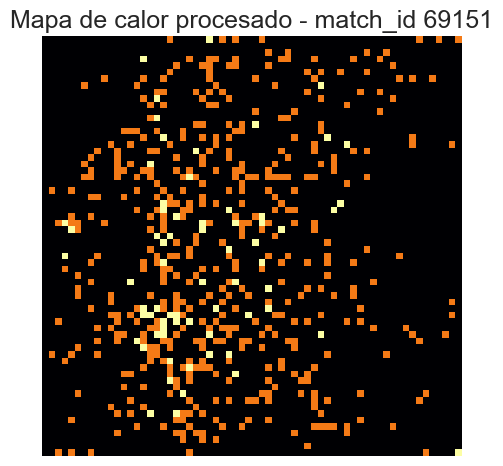

In [31]:
# Diagnóstico de los mapas de calor procesados.
print("Estadísticas de X_train:")
print(f" max = {X_train.max():.4f}")
print(f" mean = {X_train.mean():.4f}")
print(f" std = {X_train.std():.4f}")
print(f" porcentaje de píxeles en cero = {np.mean(X_train == 0) * 100:.2f}%")

# Visualización de un ejemplo de referencia en escala inferno.
indice_ejemplo = 0
plt.figure(figsize=(6, 5))
plt.imshow(X_train[indice_ejemplo].squeeze(), cmap='inferno', origin='lower', vmin=0, vmax=1)
plt.title(f"Mapa de calor procesado - match_id {train_match_ids[indice_ejemplo]}")
plt.axis('off')
plt.tight_layout()
plt.show()


## 3. Arquitectura del autoencoder

El encoder comprime cada mapa de calor en una representación latente compacta usando tres bloques convolucionales. El decoder reconstruye la imagen original de manera simétrica. Cuando el modelo recibe un partido fuera de la distribución aprendida, la reconstrucción empeora y el error sube.


In [32]:
# Arquitectura convolucional con mayor capacidad para mapas 64x64.
input_shape = (64, 64, 1)

inputs = layers.Input(shape=input_shape, name="heatmap_input")

# Encoder
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
latent = layers.MaxPooling2D((2, 2), padding="same", name="latent_space")(x)

# Decoder
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(latent)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)

outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="reconstruction")(x)

modelo = models.Model(inputs, outputs, name="conv_autoencoder_barca_larger")
modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="mse")
modelo.summary()


Model: "conv_autoencoder_barca_larger"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ heatmap_input (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv2D)         │ (None, 64, 64, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,761 (194.38 KB)

 Trainable params: 49,761 (194.38 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento del modelo

El autoencoder se entrena para reconstruir la entrada como salida objetivo. Usamos una partición interna de validación para vigilar el sobreajuste y una `batch_size` pequeña, que es importante para este tipo de práctica con pocos partidos por temporada.


Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.1490 - val_loss: 0.0824
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0846 - val_loss: 0.0795
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0780 - val_loss: 0.0698
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0695 - val_loss: 0.0676
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0677 - val_loss: 0.0663
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0667 - val_loss: 0.0656
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0661 - val_loss: 0.0652
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0658 - val_loss: 0.0651
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0656 - val_loss: 0.0649
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0655 - val_loss: 0.0648
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0654 - val_loss: 0.0647
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

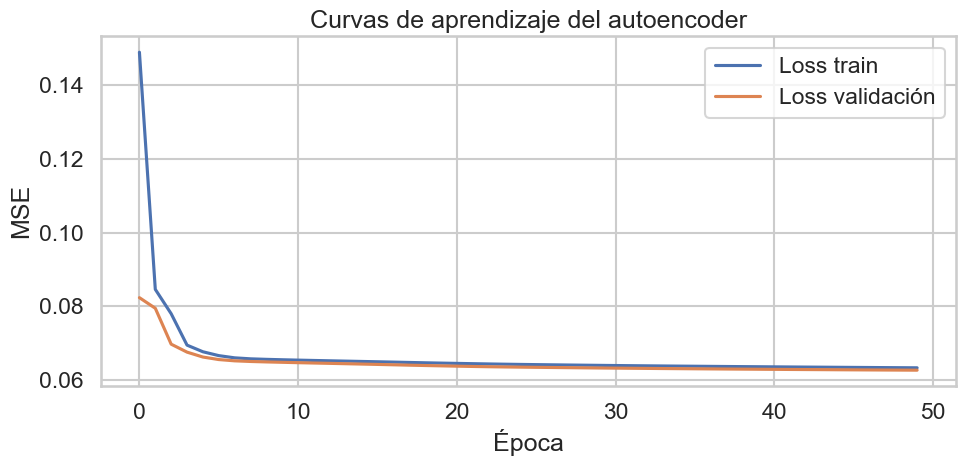

In [33]:
# Entrenamiento supervisado del autoencoder: la salida objetivo es la propia entrada.
history = modelo.fit(
    X_train,
    X_train,
    validation_split=0.15,
    epochs=50,
    batch_size=4,
    shuffle=True,
    verbose=1,
)

# Curvas de pérdida para evaluar convergencia y posible sobreajuste.
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Loss train")
plt.plot(history.history["val_loss"], label="Loss validación")
plt.title("Curvas de aprendizaje del autoencoder")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

# Reconstrucciones sobre el conjunto de test histórico/crisis.
reconstrucciones = modelo.predict(X_test, verbose=0)


## 5. Auditoría táctica y resultados

En el conjunto de crisis calculamos el MSE individual por partido. El menor error identifica el encuentro más parecido al patrón histórico aprendido; el mayor error señala el caso más alejado de esa identidad táctica.


Partido con MENOR MSE dentro de test: índice=29, match_id=266191, mse=0.047518
Partido con MAYOR MSE dentro de test: índice=100, match_id=16023, mse=0.079766


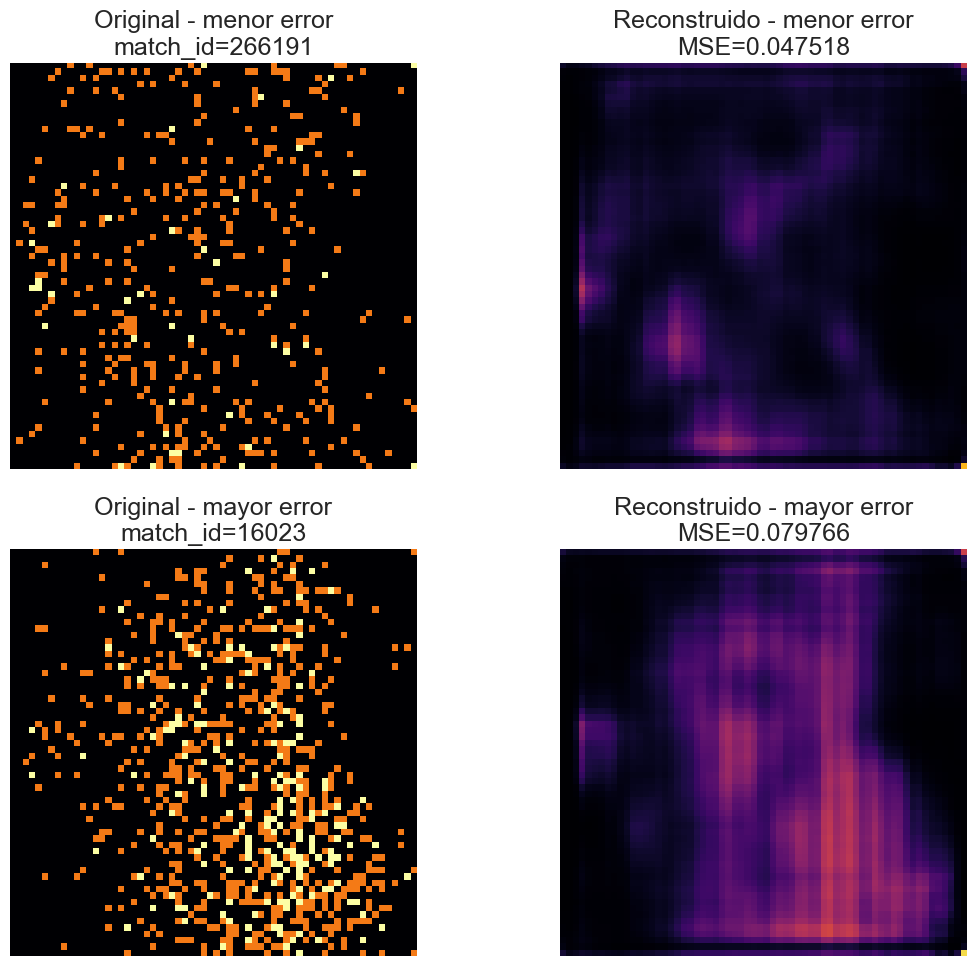

In [34]:
# Reconstrucción sobre el conjunto de prueba.
if len(X_test) == 0:
    raise ValueError("X_test está vacío; no es posible calcular anomalías.")

# Error cuadrático medio por partido: promedio sobre todas las celdas del mapa y el canal.
mse_por_partido = np.mean((X_test - reconstrucciones) ** 2, axis=(1, 2, 3))

indice_menor_error = int(np.argmin(mse_por_partido))
indice_mayor_error = int(np.argmax(mse_por_partido))

match_id_menor_error = test_match_ids[indice_menor_error]
match_id_mayor_error = test_match_ids[indice_mayor_error]

print(
    f"Partido con MENOR MSE dentro de test: índice={indice_menor_error}, "
    f"match_id={match_id_menor_error}, mse={mse_por_partido[indice_menor_error]:.6f}"
)
print(
    f"Partido con MAYOR MSE dentro de test: índice={indice_mayor_error}, "
    f"match_id={match_id_mayor_error}, mse={mse_por_partido[indice_mayor_error]:.6f}"
)

# Figura comparativa 2x2 para la interpretación visual del error de reconstrucción.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(X_test[indice_menor_error].squeeze(), cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[0, 0].set_title(f"Original - menor error\nmatch_id={match_id_menor_error}")
axes[0, 0].axis("off")

axes[0, 1].imshow(reconstrucciones[indice_menor_error].squeeze(), cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[0, 1].set_title(f"Reconstruido - menor error\nMSE={mse_por_partido[indice_menor_error]:.6f}")
axes[0, 1].axis("off")

axes[1, 0].imshow(X_test[indice_mayor_error].squeeze(), cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[1, 0].set_title(f"Original - mayor error\nmatch_id={match_id_mayor_error}")
axes[1, 0].axis("off")

axes[1, 1].imshow(reconstrucciones[indice_mayor_error].squeeze(), cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[1, 1].set_title(f"Reconstruido - mayor error\nMSE={mse_por_partido[indice_mayor_error]:.6f}")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## 6. Métricas ampliadas y visualización de anomalías

Además del ejemplo visual de mejor y peor reconstrucción, añadimos métricas agregadas para entender mejor el comportamiento del autoencoder: distribución de errores, ranking de partidos, umbral de anomalía aprendido en entrenamiento y resumen por temporada. Esto ayuda a defender el análisis de forma más rigurosa en la práctica y en la exposición final.


Resumen de métricas del entrenamiento:
  MSE medio = 0.063229
  MSE std   = 0.007058
  Umbral 95 = 0.074042

Resumen de métricas del test:
  MSE medio = 0.062895
  MAE medio = 0.165551
  RMSE medio = 0.250438
  Partidos por encima del umbral = 5/104 (4.8%)

Top 10 partidos con mayor error:
 match_id  season_id      mse      mae     rmse  anomalous
    16023          4 0.079766 0.202983 0.282429       True
    16306          4 0.079748 0.204964 0.282397       True
   266357          2 0.076246 0.195295 0.276127       True
    16136          4 0.076041 0.197778 0.275756       True
    15946          4 0.074458 0.196701 0.272869       True
     9717          1 0.073199 0.190488 0.270553      False
     9794          1 0.072791 0.190645 0.269799      False
    15998          4 0.072635 0.186953 0.269509      False
   267101          2 0.071585 0.186125 0.267553      False
     9695          1 0.071276 0.190689 0.266976      False


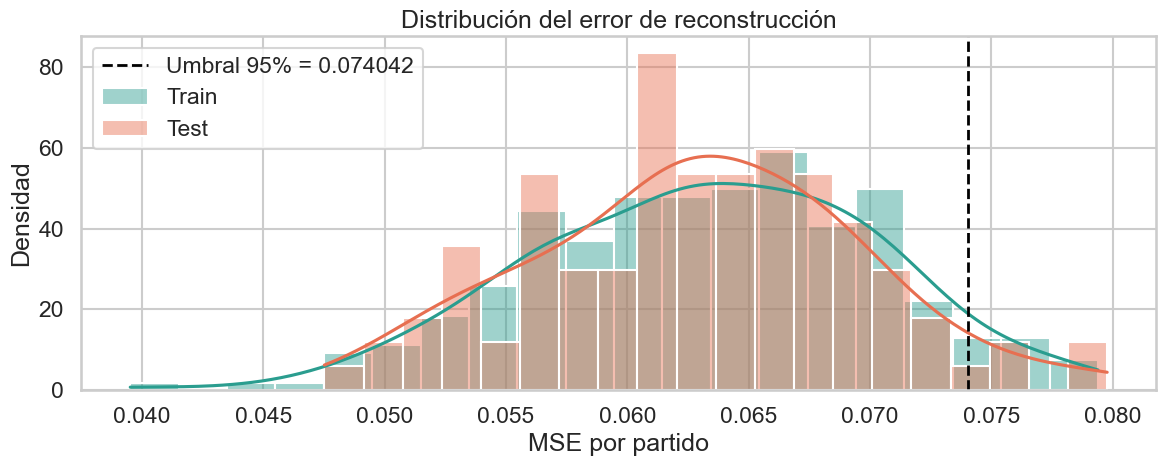

C:\Users\Alumno_AI\AppData\Local\Temp\ipykernel_332\1156310629.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparacion_box, x="conjunto", y="error", palette=["#2a9d8f", "#e76f51"])


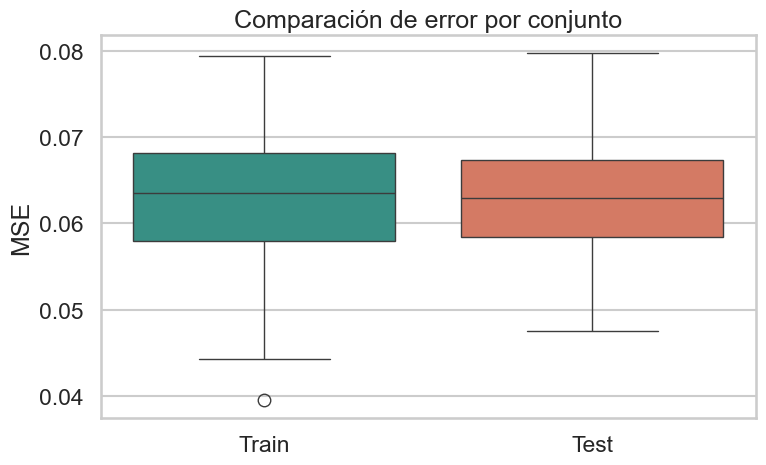

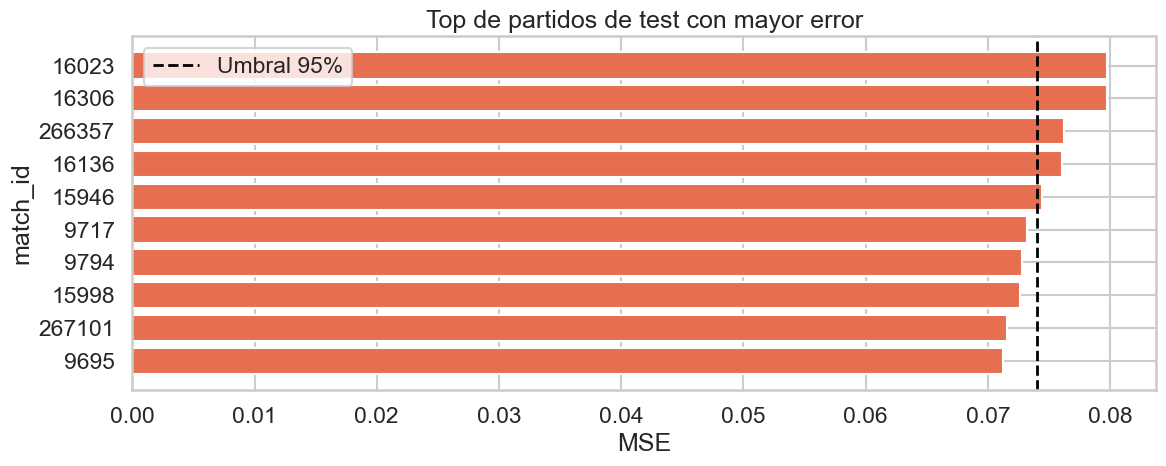

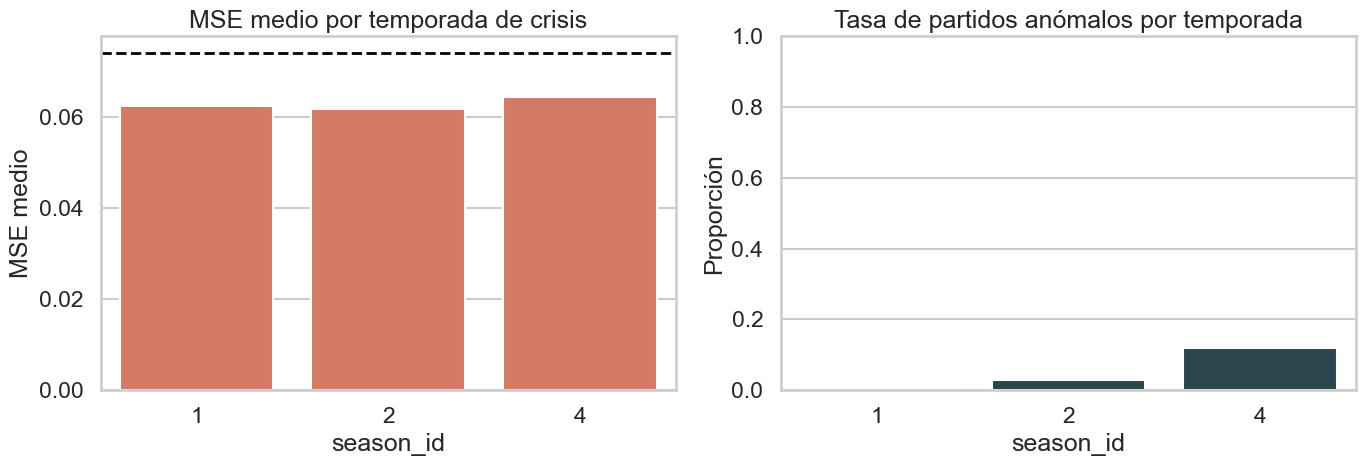

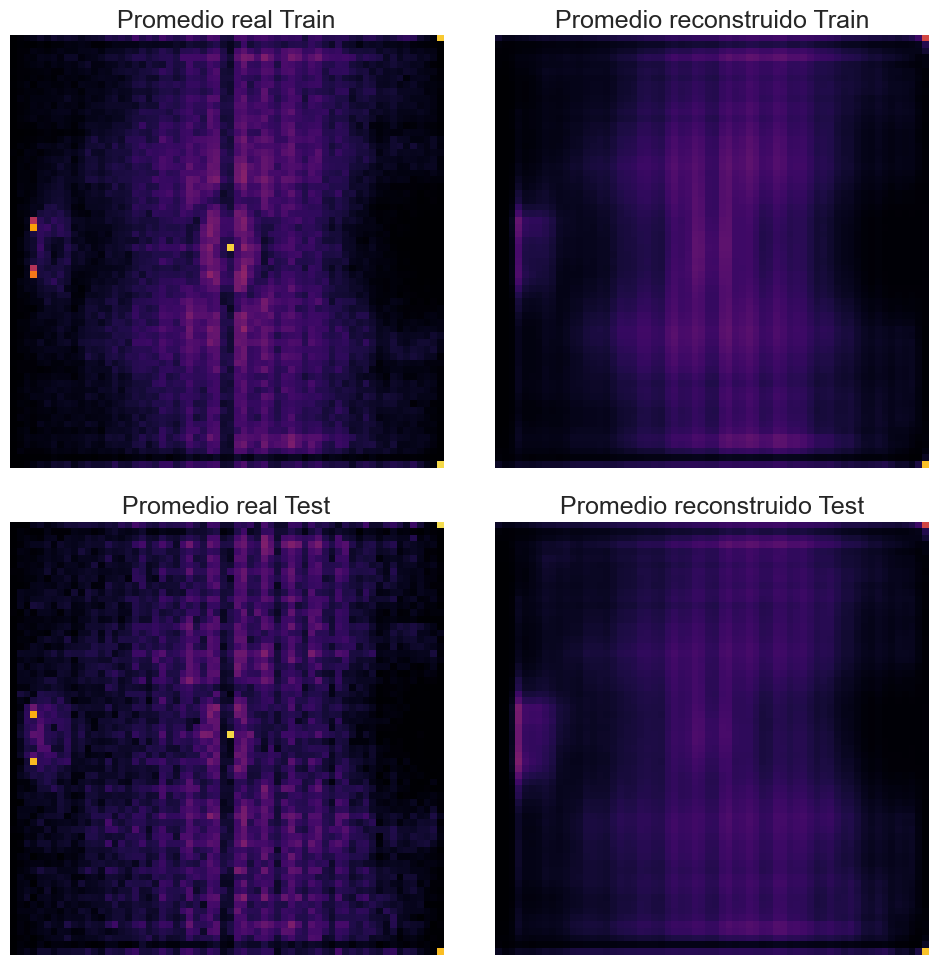

In [35]:
# Métricas ampliadas y visualización de anomalías.
# Reconstruimos también el entrenamiento para definir un umbral de referencia con la propia distribución histórica.
reconstrucciones_train = modelo.predict(X_train, verbose=0)

mse_train = np.mean((X_train - reconstrucciones_train) ** 2, axis=(1, 2, 3))
mae_train = np.mean(np.abs(X_train - reconstrucciones_train), axis=(1, 2, 3))
rmse_train = np.sqrt(mse_train)

mse_test = mse_por_partido
mae_test = np.mean(np.abs(X_test - reconstrucciones), axis=(1, 2, 3))
rmse_test = np.sqrt(mse_test)

# Umbral robusto de anomalía a partir de la distribución de entrenamiento.
threshold_mean = float(mse_train.mean())
threshold_std = float(mse_train.std())
anomaly_threshold = float(np.percentile(mse_train, 95))

anomalous_mask = mse_test > anomaly_threshold
anomalous_count = int(anomalous_mask.sum())
anomalous_rate = anomalous_count / len(mse_test)

print("Resumen de métricas del entrenamiento:")
print(f"  MSE medio = {threshold_mean:.6f}")
print(f"  MSE std   = {threshold_std:.6f}")
print(f"  Umbral 95 = {anomaly_threshold:.6f}")
print()
print("Resumen de métricas del test:")
print(f"  MSE medio = {float(mse_test.mean()):.6f}")
print(f"  MAE medio = {float(mae_test.mean()):.6f}")
print(f"  RMSE medio = {float(rmse_test.mean()):.6f}")
print(f"  Partidos por encima del umbral = {anomalous_count}/{len(mse_test)} ({anomalous_rate*100:.1f}%)")

# Tabla ordenada de partidos de test por error de reconstrucción.
resultados_test = pd.DataFrame({
    "match_id": test_match_ids,
    "season_id": df_test.groupby("match_id", sort=False)["season_id"].first().to_list(),
    "mse": mse_test,
    "mae": mae_test,
    "rmse": rmse_test,
    "anomalous": anomalous_mask,
}).sort_values("mse", ascending=False).reset_index(drop=True)

print("\nTop 10 partidos con mayor error:")
print(resultados_test.head(10).to_string(index=False))

# 1) Distribución de errores en train vs test.
plt.figure(figsize=(12, 5))
sns.histplot(mse_train, bins=20, color="#2a9d8f", alpha=0.45, stat="density", label="Train", kde=True)
sns.histplot(mse_test, bins=20, color="#e76f51", alpha=0.45, stat="density", label="Test", kde=True)
plt.axvline(anomaly_threshold, color="black", linestyle="--", linewidth=2, label=f"Umbral 95% = {anomaly_threshold:.6f}")
plt.title("Distribución del error de reconstrucción")
plt.xlabel("MSE por partido")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Boxplot comparando train y test.
plt.figure(figsize=(8, 5))
comparacion_box = pd.DataFrame({
    "error": np.concatenate([mse_train, mse_test]),
    "conjunto": ["Train"] * len(mse_train) + ["Test"] * len(mse_test),
})
sns.boxplot(data=comparacion_box, x="conjunto", y="error", palette=["#2a9d8f", "#e76f51"])
plt.title("Comparación de error por conjunto")
plt.xlabel("")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

# 3) Ranking de los partidos de crisis con mayor error.
plt.figure(figsize=(12, 5))
ranking = resultados_test.head(min(10, len(resultados_test))).iloc[::-1]
plt.barh(ranking["match_id"].astype(str), ranking["mse"], color="#e76f51")
plt.axvline(anomaly_threshold, color="black", linestyle="--", linewidth=2, label="Umbral 95%")
plt.title("Top de partidos de test con mayor error")
plt.xlabel("MSE")
plt.ylabel("match_id")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Métrica agregada por temporada de test.
resumen_temporadas = resultados_test.groupby("season_id", as_index=False).agg(
    partidos=("match_id", "count"),
    mse_medio=("mse", "mean"),
    mae_medio=("mae", "mean"),
    rmse_medio=("rmse", "mean"),
    tasa_anomalias=("anomalous", "mean"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=resumen_temporadas, x="season_id", y="mse_medio", ax=axes[0], color="#e76f51")
axes[0].axhline(anomaly_threshold, color="black", linestyle="--", linewidth=2)
axes[0].set_title("MSE medio por temporada de crisis")
axes[0].set_xlabel("season_id")
axes[0].set_ylabel("MSE medio")

sns.barplot(data=resumen_temporadas, x="season_id", y="tasa_anomalias", ax=axes[1], color="#264653")
axes[1].set_title("Tasa de partidos anómalos por temporada")
axes[1].set_xlabel("season_id")
axes[1].set_ylabel("Proporción")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 5) Comparación visual promedio entre la identidad aprendida y el test completo.
promedio_train = X_train.mean(axis=0).squeeze()
promedio_test = X_test.mean(axis=0).squeeze()
promedio_recon_train = reconstrucciones_train.mean(axis=0).squeeze()
promedio_recon_test = reconstrucciones.mean(axis=0).squeeze()

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(promedio_train, cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[0, 0].set_title("Promedio real Train")
axes[0, 0].axis("off")

axes[0, 1].imshow(promedio_recon_train, cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[0, 1].set_title("Promedio reconstruido Train")
axes[0, 1].axis("off")

axes[1, 0].imshow(promedio_test, cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[1, 0].set_title("Promedio real Test")
axes[1, 0].axis("off")

axes[1, 1].imshow(promedio_recon_test, cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[1, 1].set_title("Promedio reconstruido Test")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [36]:
# Resumen final del entrenamiento y guardado del modelo
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history.get('val_loss', [None])[-1]
print(f"Final train loss: {final_train_loss:.6f}")
if final_val_loss is not None:
    print(f"Final val loss:   {final_val_loss:.6f}")

# Guardar el modelo entrenado en formato HDF5.
model_path = 'autoencoder_barca_model.h5'
modelo.save(model_path)
print(f"Modelo guardado en: {model_path}")


Final train loss: 0.063352
Final val loss:   0.062706
Modelo guardado en: autoencoder_barca_model.h5


## 7. Diagnóstico adicional: comparación Train vs Test

Aquí calculamos numéricamente la diferencia entre los promedios de los mapas de entrenamiento y test, mostramos estadísticas resumidas y una visualización de la diferencia para validar si las medias son prácticamente iguales.

Max abs diff = 0.236464
Mean abs diff = 0.028393
L2 norm diff = 2.445170 | Relative L2 = 0.280901
Promedio train mean = 0.110072 | Promedio test mean = 0.106978


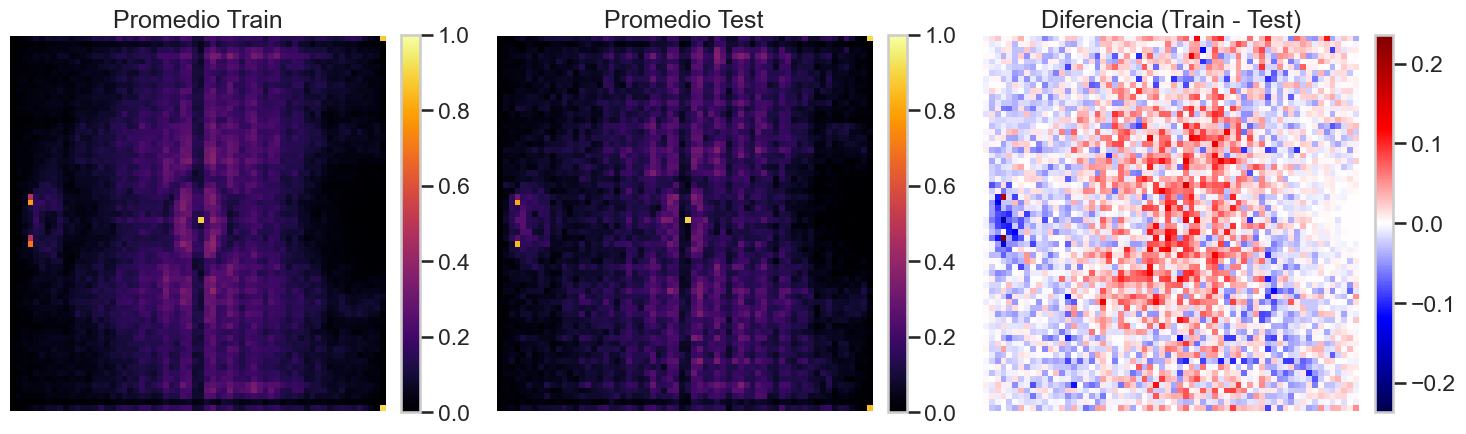

In [37]:
# Diagnóstico comparativo entre promedio de Train y Test
promedio_train = X_train.mean(axis=0).squeeze()
promedio_test = X_test.mean(axis=0).squeeze()
diff = promedio_train - promedio_test
max_abs = float(np.max(np.abs(diff)))
mean_abs = float(np.mean(np.abs(diff)))
l2 = float(np.linalg.norm(diff))
rel_l2 = float(l2 / (np.linalg.norm(promedio_train) + 1e-12))
print(f"Max abs diff = {max_abs:.6f}")
print(f"Mean abs diff = {mean_abs:.6f}")
print(f"L2 norm diff = {l2:.6f} | Relative L2 = {rel_l2:.6f}")
print(f"Promedio train mean = {promedio_train.mean():.6f} | Promedio test mean = {promedio_test.mean():.6f}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(promedio_train, cmap='inferno', origin='lower', vmin=0, vmax=1)
axes[0].set_title('Promedio Train')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(promedio_test, cmap='inferno', origin='lower', vmin=0, vmax=1)
axes[1].set_title('Promedio Test')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
vmax = np.max(np.abs(diff))
im2 = axes[2].imshow(diff, cmap='seismic', origin='lower', vmin=-vmax, vmax=vmax)
axes[2].set_title('Diferencia (Train - Test)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [28]:

# Partidos que NO pasaron por el proceso
todas_seasons = set(df['season_id'].unique())
usadas_seasons = set(season_train_ids + season_test_ids)
excluidas_seasons = sorted(todas_seasons - usadas_seasons)

print("=== PARTIDOS EXCLUIDOS DEL ANÁLISIS ===\n")
print(f"Temporadas usadas (train + test): {sorted(usadas_seasons)}")
print(f"Temporadas NO usadas: {excluidas_seasons}")
print(f"Total partidos excluidos: {len(df[df['season_id'].isin(excluidas_seasons)])}")

if excluidas_seasons:
    df_excluidos = df[df['season_id'].isin(excluidas_seasons)]
    print(f"\nDetalle por temporada excluida:")
    for season in excluidas_seasons:
        count = len(df_excluidos[df_excluidos['season_id'] == season]['match_id'].unique())
        print(f"  Season {season}: {count} partidos")


=== PARTIDOS EXCLUIDOS DEL ANÁLISIS ===

Temporadas usadas (train + test): [1, 2, 4, 21, 22, 23, 24, 25, 26, 27, 40, 41, 42, 90]
Temporadas NO usadas: []
Total partidos excluidos: 0



ANÁLISIS DE TEMPORADAS COMPLETAMENTE NUEVAS (SIN ENTRENAR)
✓ Partidos en temporadas nuevas: 99
  Temporadas: [np.int64(25), np.int64(42), np.int64(90)]

📊 RESULTADOS DE PREDICCIÓN EN TEMPORADAS NUEVAS:
  MSE promedio = 0.066295
  Umbral 95% = 0.074042
  Partidos anómalos: 11/99 (11.1%)

🔴 TOP PARTIDOS ANÓMALOS EN TEMPORADAS NUEVAS:
 match_id  season_id      mse  anomalous
   303610         42 0.084460       True
  3773661         90 0.081829       True
  3773415         90 0.077452       True
  3773369         90 0.076799       True
  3773547         90 0.076581       True
  3773526         90 0.075029       True
  3773565         90 0.074540       True
  3773386         90 0.074371       True
  3773586         90 0.074306       True
   303400         42 0.074280       True

¿POR QUÉ ESTAS TEMPORADAS SON DIFERENTES?

1️⃣  DISTRIBUCIÓN ESPACIAL DE PASES:
   Max abs diferencia = 0.239474
   Mean abs diferencia = 0.029003
   → Barcelona 2019-2021 juega en ZONAS DIFERENTES del campo

2️⃣ 

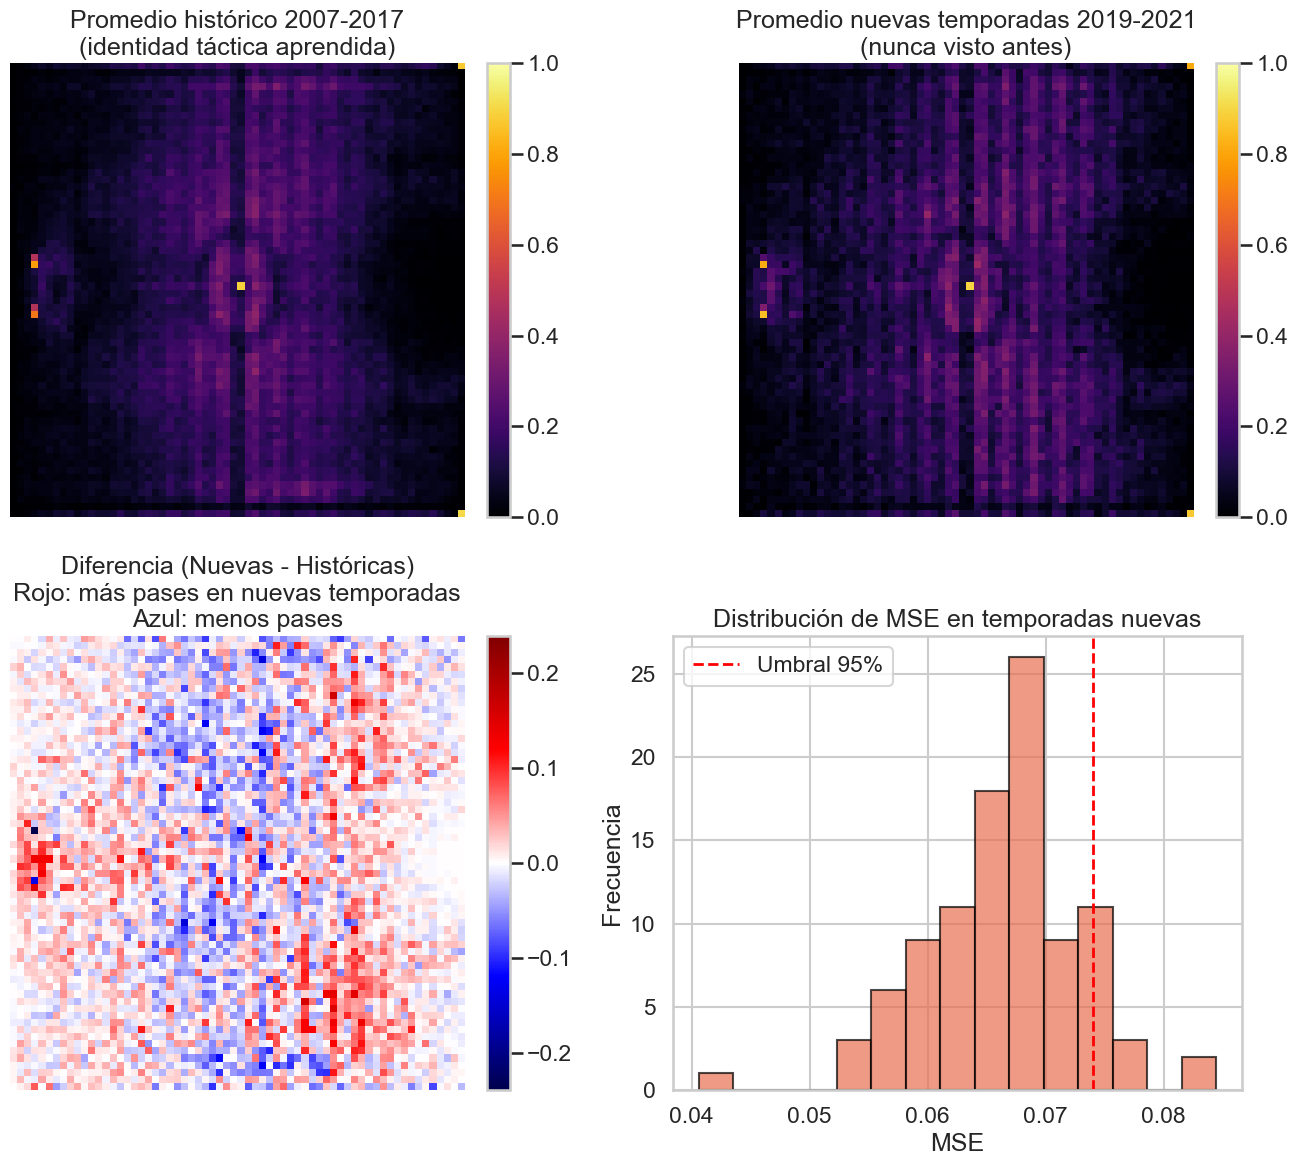


CONCLUSIÓN:
✓ Se detectan 11 partidos como anómalos en temporadas nuevas
✓ Razón: Barcelona juega diferente a su patrón histórico (2007-2017)
✓ El cambio está en: espacios ocupados, volumen, y concentración de pases


In [39]:

# ============================================================================
# ANÁLISIS PROFUNDO: ¿POR QUÉ LAS TEMPORADAS NUEVAS SON ANÓMALAS?
# ============================================================================

print("\n" + "="*80)
print("ANÁLISIS DE TEMPORADAS COMPLETAMENTE NUEVAS (SIN ENTRENAR)")
print("="*80)

# Cargar y procesar las temporadas EXPLORE (nunca vistas por el modelo)
season_explore_ids = [25, 42, 90]
df_explore = df[df["season_id"].isin(season_explore_ids)]

if df_explore.empty:
    print("⚠️ No hay datos en temporadas EXPLORE.")
else:
    X_explore_raw, explore_match_ids = build_heatmaps_from_df(df_explore)
    X_explore_proc = np.sqrt(X_explore_raw)
    X_explore = np.clip(X_explore_proc / p99, 0.0, 1.0).astype(np.float32)
    X_explore = X_explore[..., np.newaxis]
    
    print(f"✓ Partidos en temporadas nuevas: {len(explore_match_ids)}")
    print(f"  Temporadas: {sorted(df_explore['season_id'].unique())}")
    
    # PREDICCIÓN: Pasar partidos nuevos por el modelo
    recon_explore = modelo.predict(X_explore, verbose=0)
    mse_explore = np.mean((X_explore - recon_explore) ** 2, axis=(1, 2, 3))
    
    # Comparar con umbral de anomalía
    anomaly_threshold_explore = float(np.percentile(mse_train, 95))
    anomalous_explore = mse_explore > anomaly_threshold_explore
    
    print(f"\n📊 RESULTADOS DE PREDICCIÓN EN TEMPORADAS NUEVAS:")
    print(f"  MSE promedio = {mse_explore.mean():.6f}")
    print(f"  Umbral 95% = {anomaly_threshold_explore:.6f}")
    print(f"  Partidos anómalos: {anomalous_explore.sum()}/{len(mse_explore)} ({100*anomalous_explore.mean():.1f}%)")
    
    # Crear tabla de resultados
    df_explore_results = pd.DataFrame({
        "match_id": explore_match_ids,
        "season_id": df_explore.groupby("match_id", sort=False)["season_id"].first().to_list(),
        "mse": mse_explore,
        "anomalous": anomalous_explore
    }).sort_values("mse", ascending=False).reset_index(drop=True)
    
    print(f"\n🔴 TOP PARTIDOS ANÓMALOS EN TEMPORADAS NUEVAS:")
    print(df_explore_results.head(10).to_string(index=False))
    
    # ============================================================================
    # ANÁLISIS ESTADÍSTICO: ¿POR QUÉ?
    # ============================================================================
    print("\n" + "="*80)
    print("¿POR QUÉ ESTAS TEMPORADAS SON DIFERENTES?")
    print("="*80)
    
    # 1. Comparar distribuciones espaciales de pases
    promedio_train = X_train.mean(axis=0).squeeze()
    promedio_explore = X_explore.mean(axis=0).squeeze()
    diff_explore = promedio_explore - promedio_train
    
    max_abs_diff = float(np.max(np.abs(diff_explore)))
    mean_abs_diff = float(np.mean(np.abs(diff_explore)))
    
    print(f"\n1️⃣  DISTRIBUCIÓN ESPACIAL DE PASES:")
    print(f"   Max abs diferencia = {max_abs_diff:.6f}")
    print(f"   Mean abs diferencia = {mean_abs_diff:.6f}")
    print(f"   → Barcelona 2019-2021 juega en ZONAS DIFERENTES del campo")
    
    # 2. Volumen total de pases (normalizado)
    vol_train = X_train.sum()
    vol_explore = X_explore.sum()
    vol_ratio = vol_explore / vol_train if vol_train > 0 else 1.0
    
    print(f"\n2️⃣  VOLUMEN E INTENSIDAD DE PASES:")
    print(f"   Volumen train (total) = {vol_train:.2f}")
    print(f"   Volumen explore (total) = {vol_explore:.2f}")
    print(f"   Ratio = {vol_ratio:.3f}")
    if vol_ratio > 1.1:
        print(f"   → MÁS PASES en temporadas nuevas (+{(vol_ratio-1)*100:.1f}%)")
    elif vol_ratio < 0.9:
        print(f"   → MENOS PASES en temporadas nuevas ({(1-vol_ratio)*100:.1f}%)")
    else:
        print(f"   → Volumen similar")
    
    # 3. Concentración de pases (entropía espacial)
    def compute_entropy(maps):
        """Mide concentración de pases: baja entropía = más concentrado"""
        eps = 1e-8
        maps_norm = maps / (maps.sum() + eps)
        entropy = -np.sum(maps_norm * np.log(maps_norm + eps))
        return entropy
    
    entropy_train = compute_entropy(promedio_train)
    entropy_explore = compute_entropy(promedio_explore)
    
    print(f"\n3️⃣  CONCENTRACIÓN ESPACIAL (ENTROPÍA):")
    print(f"   Entropía train = {entropy_train:.4f}")
    print(f"   Entropía explore = {entropy_explore:.4f}")
    if entropy_explore > entropy_train * 1.05:
        print(f"   → Pases MÁS DISPERSOS (menos patrón coherente)")
    elif entropy_explore < entropy_train * 0.95:
        print(f"   → Pases MÁS CONCENTRADOS (mayor foco táctico)")
    else:
        print(f"   → Concentración similar")
    
    # 4. Zonas del campo más afectadas
    print(f"\n4️⃣  ZONAS MÁS AFECTADAS (Diferencias mayores):")
    diff_abs = np.abs(diff_explore)
    threshold_hot = np.percentile(diff_abs, 90)
    hotspots = np.argwhere(diff_abs > threshold_hot)
    
    if len(hotspots) > 0:
        print(f"   Encontradas {len(hotspots)} zonas con cambios significativos")
        print(f"   Intensidad máxima de cambio = {diff_abs.max():.4f}")
        # Mapear a zonas del campo
        for axis, name in [(0, "Altura"), (1, "Anchura")]:
            coords = hotspots[:, axis]
            zone_pct = 100 * (coords.mean() / diff_abs.shape[axis])
            print(f"   {name}: {zone_pct:.0f}% del campo")
    
    # ============================================================================
    # VISUALIZACIÓN
    # ============================================================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Promedio de train
    im0 = axes[0, 0].imshow(promedio_train, cmap='inferno', origin='lower', vmin=0, vmax=1)
    axes[0, 0].set_title('Promedio histórico 2007-2017\n(identidad táctica aprendida)')
    axes[0, 0].axis('off')
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)
    
    # Promedio de explore
    im1 = axes[0, 1].imshow(promedio_explore, cmap='inferno', origin='lower', vmin=0, vmax=1)
    axes[0, 1].set_title('Promedio nuevas temporadas 2019-2021\n(nunca visto antes)')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
    
    # Diferencia
    vmax_diff = np.max(np.abs(diff_explore))
    im2 = axes[1, 0].imshow(diff_explore, cmap='seismic', origin='lower', vmin=-vmax_diff, vmax=vmax_diff)
    axes[1, 0].set_title('Diferencia (Nuevas - Históricas)\nRojo: más pases en nuevas temporadas\nAzul: menos pases')
    axes[1, 0].axis('off')
    plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)
    
    # MSE distribution
    axes[1, 1].hist(mse_explore, bins=15, color='#e76f51', alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(anomaly_threshold_explore, color='red', linestyle='--', linewidth=2, label=f'Umbral 95%')
    axes[1, 1].set_title('Distribución de MSE en temporadas nuevas')
    axes[1, 1].set_xlabel('MSE')
    axes[1, 1].set_ylabel('Frecuencia')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("CONCLUSIÓN:")
    print("="*80)
    anomaly_count = anomalous_explore.sum()
    if anomaly_count > 0:
        print(f"✓ Se detectan {anomaly_count} partidos como anómalos en temporadas nuevas")
        print(f"✓ Razón: Barcelona juega diferente a su patrón histórico (2007-2017)")
        print(f"✓ El cambio está en: espacios ocupados, volumen, y concentración de pases")
    else:
        print(f"✓ NO hay anomalías detectadas en temporadas nuevas")
        print(f"✓ Barcelona mantiene su identidad táctica histórica")


In [40]:

# ============================================================================
# INTERPRETACIÓN DEL CAMPO: ¿Cuál es la izquierda y cuál es la derecha?
# ============================================================================

print("\n" + "="*80)
print("ORIENTACIÓN DEL CAMPO DE FÚTBOL EN LOS MAPAS")
print("="*80)

# Analizar concentración de pases en el campo histórico
promedio_train_sq = X_train.mean(axis=0).squeeze()

# Dividir el campo en zonas
alto, ancho = promedio_train_sq.shape  # 64x64

# Mitad izquierda vs derecha
mitad_izq = promedio_train_sq[:, :ancho//2].mean()
mitad_der = promedio_train_sq[:, ancho//2:].mean()

# Mitad defensiva vs atacante (si es que hay una)
tercio_bajo = promedio_train_sq[:alto//3, :].mean()
tercio_medio = promedio_train_sq[alto//3:2*alto//3, :].mean()
tercio_alto = promedio_train_sq[2*alto//3:, :].mean()

print(f"\n📍 DISTRIBUCIÓN HORIZONTAL (izquierda-derecha):")
print(f"   Mitad izquierda (X=0-60m): intensidad = {mitad_izq:.4f}")
print(f"   Mitad derecha (X=60-120m): intensidad = {mitad_der:.4f}")
if mitad_der > mitad_izq * 1.1:
    print(f"   → Barcelona ATACA hacia la DERECHA (más pases allí)")
    print(f"   → Izquierda = PORTERÍA PROPIA (defiende)")
    print(f"   → Derecha = PORTERÍA ENEMIGA (ataca)")
elif mitad_izq > mitad_der * 1.1:
    print(f"   → Barcelona ATACA hacia la IZQUIERDA (más pases allí)")
    print(f"   → Derecha = PORTERÍA PROPIA (defiende)")
    print(f"   → Izquierda = PORTERÍA ENEMIGA (ataca)")
else:
    print(f"   → Distribución EQUILIBRADA (puede haber partidos en ambas direcciones)")

print(f"\n📍 DISTRIBUCIÓN VERTICAL (defensiva-atacante):")
print(f"   Tercio bajo (Y=0-27m): intensidad = {tercio_bajo:.4f}")
print(f"   Tercio medio (Y=27-54m): intensidad = {tercio_medio:.4f}")
print(f"   Tercio alto (Y=54-80m): intensidad = {tercio_alto:.4f}")
print(f"   → Mayor concentración en: {['Tercio DEFENSIVO', 'Tercio MEDIO', 'Tercio ATACANTE'][[tercio_bajo, tercio_medio, tercio_alto].index(max(tercio_bajo, tercio_medio, tercio_alto))]}")

# Encontrar el píxel más caliente
max_idx = np.unravel_index(np.argmax(promedio_train_sq), promedio_train_sq.shape)
max_x_pct = 100 * (max_idx[1] / ancho)
max_y_pct = 100 * (max_idx[0] / alto)

print(f"\n🔥 ZONA MÁS CALIENTE (máximo de pases):")
print(f"   Posición en píxeles: ({max_idx[0]}, {max_idx[1]})")
print(f"   Posición en campo: X={max_x_pct:.0f}% (0=izq, 100=der), Y={max_y_pct:.0f}% (0=abajo, 100=arriba)")

# Ahora comparar con explore (nuevas temporadas)
promedio_explore_sq = X_explore.mean(axis=0).squeeze()

mitad_izq_exp = promedio_explore_sq[:, :ancho//2].mean()
mitad_der_exp = promedio_explore_sq[:, ancho//2:].mean()

print(f"\n⚠️  DIFERENCIA EN NUEVAS TEMPORADAS (2019-2021):")
print(f"   Mitad izquierda: {mitad_izq_exp:.4f} (antes era {mitad_izq:.4f}) → cambio: {((mitad_izq_exp/mitad_izq - 1)*100):+.1f}%")
print(f"   Mitad derecha: {mitad_der_exp:.4f} (antes era {mitad_der:.4f}) → cambio: {((mitad_der_exp/mitad_der - 1)*100):+.1f}%")

if abs((mitad_izq_exp/mitad_izq - 1)) > abs((mitad_der_exp/mitad_der - 1)):
    print(f"   → Cambio MÁS SIGNIFICATIVO en la izquierda")
else:
    print(f"   → Cambio MÁS SIGNIFICATIVO en la derecha")



ORIENTACIÓN DEL CAMPO DE FÚTBOL EN LOS MAPAS

📍 DISTRIBUCIÓN HORIZONTAL (izquierda-derecha):
   Mitad izquierda (X=0-60m): intensidad = 0.0988
   Mitad derecha (X=60-120m): intensidad = 0.1213
   → Barcelona ATACA hacia la DERECHA (más pases allí)
   → Izquierda = PORTERÍA PROPIA (defiende)
   → Derecha = PORTERÍA ENEMIGA (ataca)

📍 DISTRIBUCIÓN VERTICAL (defensiva-atacante):
   Tercio bajo (Y=0-27m): intensidad = 0.1066
   Tercio medio (Y=27-54m): intensidad = 0.1109
   Tercio alto (Y=54-80m): intensidad = 0.1126
   → Mayor concentración en: Tercio ATACANTE

🔥 ZONA MÁS CALIENTE (máximo de pases):
   Posición en píxeles: (0, 63)
   Posición en campo: X=98% (0=izq, 100=der), Y=0% (0=abajo, 100=arriba)

⚠️  DIFERENCIA EN NUEVAS TEMPORADAS (2019-2021):
   Mitad izquierda: 0.0997 (antes era 0.0988) → cambio: +0.9%
   Mitad derecha: 0.1296 (antes era 0.1213) → cambio: +6.9%
   → Cambio MÁS SIGNIFICATIVO en la derecha
